In [1]:
import geopandas as gpd
import pandas as pd
from useful_functions import *
import pickle
import time
import resource_bifiltration as RB
import importlib

# importlib.reload(RB)

import sys
from contextlib import redirect_stdout
from datetime import datetime
import numpy as np
import networkx as nx

from tqdm.notebook import tqdm

In [2]:
########### Packages for plotting
import matplotlib as mpl
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['font.size'] = 18

In [3]:
# parameters
qs = np.arange(0, 31, 6)
rs = np.arange(2000, 999, -200)

score_col = 'acres'

thresh_type = 'count'
len_thresh = 1000

# thresh_type = 'areaperc'
# len_thresh = 0.1

all_params = {
              'rs': rs, 
              'qs': qs, 
              'quality score col': score_col, 
              'threshold type': thresh_type, 
              'threshold': len_thresh
             }

path_to_files = 'geographic_data/'
results_folder = 'Results_Parks_Resource/2026-07-30'


fileextra = f'_{thresh_type}_{str(len_thresh).replace('.', 'p')}'


blocks = gpd.read_file(path_to_files + 'chicago_blocks.shp')
parks = gpd.read_file(path_to_files + 'parks.shp')
# ratings = pd.read_csv(path_to_files + "park_ratings_complete.csv")

G = adjacency_graph(blocks)

D = np.load(path_to_files + 'parks_distances_l1.npy')

rb = RB.ResourceBifiltration(scores = parks[score_col].values, D = D, G = G)

In [4]:
filename = f'{results_folder}/PARKS_post_initial_merge{fileextra}.pkl'

with open(f'{filename}', 'rb') as file:
    all_TCs = pickle.load(file)

In [5]:
with open(f'{results_folder}/PARKS_PARAMS_count_1000.pkl', 'rb') as file:
    param_dictionary = pickle.load(file)

In [6]:
rs = param_dictionary['rs']
qs = param_dictionary['qs']
score_col = param_dictionary['quality score col']
thresh_type = param_dictionary['threshold type']
len_thresh = param_dictionary['threshold']

# Final merging step

In [7]:
mergethreshold = 0.9
fileextra += f'_{str(mergethreshold).replace('.', 'p')}' 

# Post process merging
overlapamt = np.zeros([len(all_TCs),len(all_TCs)])

for i, TC1 in enumerate(all_TCs):
        
        all_sets1 = list(TC1.C_reps.values())
        TC1_max_rep = set.union(*all_sets1)
            
        for j, TC2 in enumerate(all_TCs):
            if i<j:
                all_sets2 = list(TC2.C_reps.values())
                TC2_max_rep = set.union(*all_sets2)

                amt_1_in_2 = len(TC2_max_rep.intersection(TC1_max_rep)) / len(TC2_max_rep)
                amt_2_in_1 = len(TC1_max_rep.intersection(TC2_max_rep)) / len(TC1_max_rep)

                overlapamt[i,j] = max(amt_1_in_2, amt_2_in_1)
                overlapamt[j,i] = overlapamt[i,j]
            elif i == j:
                 overlapamt[i,j] = 1

G = nx.Graph()
G.add_nodes_from(range(len(all_TCs)))

# Only look at upper triangle to avoid duplicate edges
rows, cols = np.where(np.triu(overlapamt, k=1) > mergethreshold)

edges = [(r, c, overlapamt[r, c]) for r, c in zip(rows, cols)]
G.add_weighted_edges_from(edges)

singletons = [node for node, degree in G.degree() if degree == 0]
G.remove_nodes_from(singletons)

nomerge_needed_dicts = []
for tc in [all_TCs[i] for i in singletons]:
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)
        lifetime = len(tc.C_reps.keys())
        plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}

        nomerge_needed_dicts.append(plotting_dict)


# Get connected components as subgraphs
components = [G.subgraph(c) for c in nx.connected_components(G)]

# # Classify components into three lists
# non_trees = [c for c in components if not nx.is_tree(c)]
# pairs     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() == 2]
# trees     = [c for c in components if nx.is_tree(c) and c.number_of_nodes() != 2]

print(f"Number of components: {len(components)}")
# print(f"Number of non-trees:  {len(non_trees)}")
# print(f"Number of pairs:      {len(pairs)}")
# print(f"Number of trees:      {len(trees)}")

Number of components: 48


In [8]:
colors=['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']
colors = colors+colors+colors+colors+colors+colors+colors+colors+colors
for i, c in enumerate(components):
    tccomp = [all_TCs[i] for i in c.nodes]
    fig, ax = plt.subplots(1,3, figsize=(10,3))
    # new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    nodecolors = []
    for j,tc in enumerate(tccomp):
        all_sets = list(tc.C_reps.values())
        max_rep = set.union(*all_sets)

        currentmaxrep = blocks[blocks.index.isin(max_rep)]
        union_mr = currentmaxrep.union_all()
        mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

        mr.plot(ax=ax[1], edgecolor=colors[j], facecolor='none', label=j)
        nodecolors.append(colors[j])

    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    currentmaxrep = blocks[blocks.index.isin(max_rep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)
    mr.plot(ax=ax[0], color='pink', label=j)

    ax[0].axis('off')
    ax[1].axis('off')

    nx.draw(c,ax=ax[2], node_color=nodecolors, with_labels=False, node_size=70)

    plt.savefig(f'{results_folder}/TEMP/Component{i}.png', bbox_inches = 'tight', dpi = 300)
    plt.close()

In [9]:
merged_dicts = []
for c in components:

    tccomp = [all_TCs[i] for i in c.nodes]
    new_tc = merge_dicts_v2(*[TC.C_reps for TC in tccomp])
    all_sets = list(new_tc.values())
    max_rep = set.union(*all_sets)
    lifetime = len(new_tc.keys())
    plotting_dict = {'maxrep': max_rep, 'lifetime': lifetime}
            
    merged_dicts.append(plotting_dict)

all_dicts = nomerge_needed_dicts + merged_dicts

with open(f'{results_folder}/PARKS_final_step_{fileextra}.pkl', 'wb') as file:
    pickle.dump(all_dicts, file)

# NEW Plotting

In [10]:
TCC = all_dicts

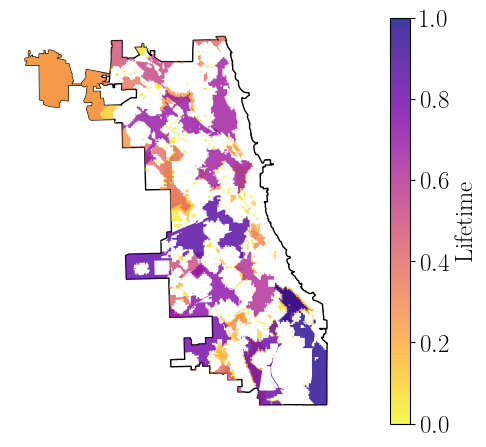

In [11]:
########## All Maximal Components, colored by range ##########
cmap = mpl.colormaps['plasma_r']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

plottingalph = 0.8

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(figsize=(10,5))
boundary.plot(ax=ax, color='black', linewidth=1)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=False)


# sorted_TCs = [x for (x,_,_) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# sorted_color_mapvals = [z for (_,_,z) in sorted(zip(all_TCs,normalized_values,color_mapvals), key=lambda pair: pair[1])]
# print(sorted_TCs)

for i, TC in enumerate(sorted_comps): #enumerate(all_TCs):
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    mr.plot(ax=ax, color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, alpha=plottingalph) 
cbar.set_label('Lifetime')

plt.tight_layout()
plt.axis('off')

plt.savefig(f'{results_folder}/PARKS_Maxrep_ALL_lifetime{fileextra}.png', bbox_inches = 'tight', dpi = 300)

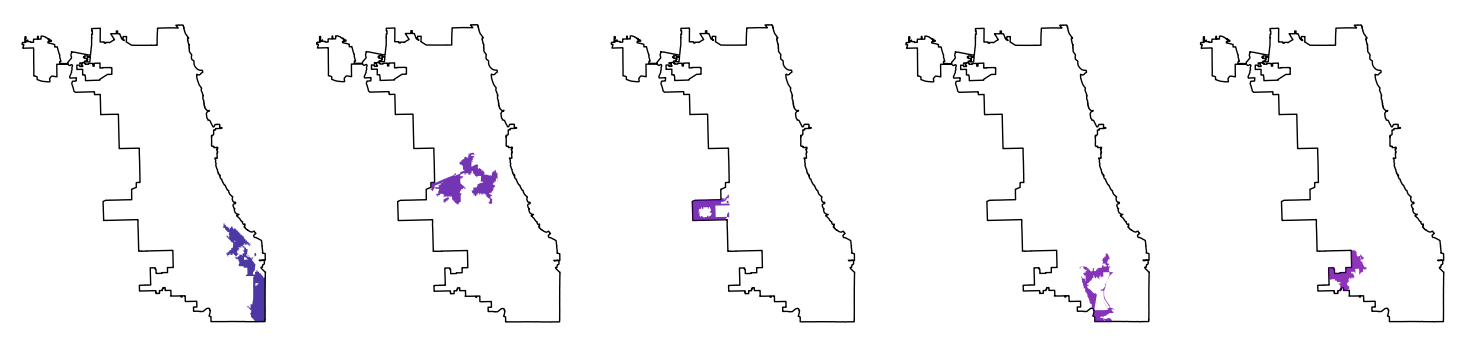

In [12]:
########## Top 10 components in individual figures ##########
plt.rcParams['font.size'] = 18

cmap = mpl.colormaps['plasma_r']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

plottingalph = 0.8

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=True)

fig, ax = plt.subplots(1,5,figsize=(15,12))
# boundary.plot(ax=ax, color='black', linewidth=1)

# axes = [ax]*10
axes = ax.flatten()

for i, TC in enumerate(sorted_comps[:5]): #enumerate(all_TCs):
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    boundary.plot(ax=axes[i], color='black', linewidth=1)

    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    mr.plot(ax=axes[i], color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

    axes[i].axis('off')


# plt.suptitle('Top 10 Maximal Components Based on Range')
# sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # required for older versions of matplotlib
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label('Range', fontsize=20)

plt.tight_layout()

plt.savefig(f'{results_folder}/PARKS_Maxrep_SepFigs_lifetime.png', bbox_inches = 'tight', dpi = 300)

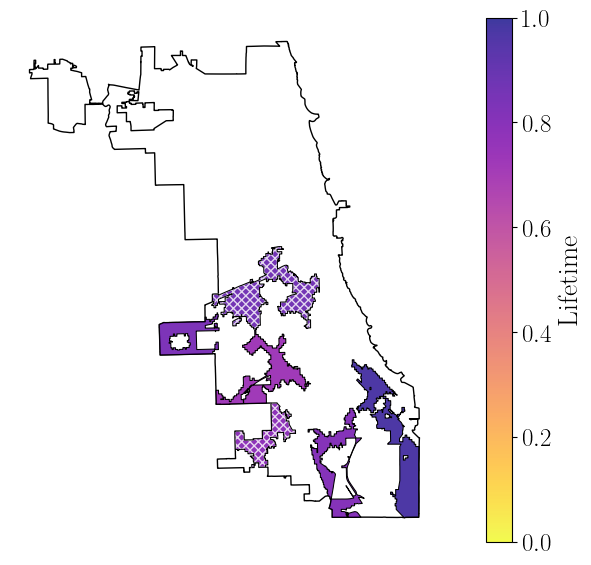

In [23]:
########## Top 10 components in individual figures ##########
plt.rcParams['font.size'] = 18

cmap = mpl.colormaps['plasma_r']
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # scale from 0 to 1

union_geom = blocks.union_all()
boundary = gpd.GeoSeries(union_geom.boundary)

fig, ax = plt.subplots(1,1,figsize=(10,6))
boundary.plot(ax=ax, color='black', linewidth=1)

sorted_comps = sorted(TCC, key=lambda x: x["lifetime"], reverse=True)

axes = [ax]*100
# axes = ax.flatten()

for i, TC in enumerate(sorted_comps[0:6]): 
    maxrep = TC['maxrep']
    lifetime = TC['lifetime']/ (len(rs) * len(qs))

    # if lifetime < 0.7: continue


    currentmaxrep = blocks[blocks.index.isin(maxrep)]
    union_mr = currentmaxrep.union_all()
    mr = gpd.GeoSeries(union_mr, crs=blocks.crs)

    if i in [1,4]:
        mr.plot(ax=axes[i], color=cmap(lifetime), alpha=plottingalph, zorder=(i+1), hatch ="xxxx", edgecolor='white')
    else:
        mr.plot(ax=axes[i], color=cmap(lifetime), alpha=plottingalph, zorder=(i+1))

    mr.boundary.plot(ax=axes[i], color='k', linewidth=0.75,zorder=100) #, linestyle='dashed')
    

    axes[i].axis('off')

# plt.suptitle('Top 10 Maximal Components Based on Range')
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, alpha=0.8)
cbar.set_label('Lifetime', fontsize=20)


plt.tight_layout()

plt.savefig(f'{results_folder}/Parks_Maxrep_topN_lifetime.png', bbox_inches = 'tight', dpi = 300)

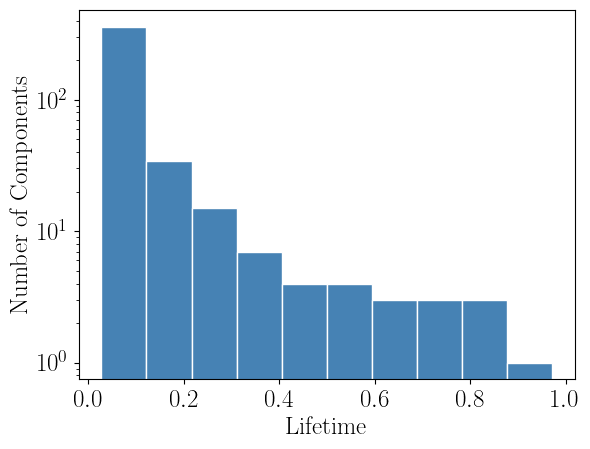

In [24]:
plt.hist([sorted_comps[i]['lifetime']/(len(rs) * len(qs)) for i in range(len(sorted_comps))], bins=10,
         edgecolor='white', color='steelblue')
plt.yscale("log")

plt.xlabel('Lifetime')
plt.ylabel('Number of Components')

plt.savefig(f'{results_folder}/PARKS_Lifetime_histogram.png', bbox_inches = 'tight', dpi = 300)

# Grid Plots for Paper

In [26]:
G = adjacency_graph(blocks)

for i in range(len(G.nodes)):

    for r in rs:
        G.nodes[i][r]=rb.f(i,r)

In [27]:
for u, v in G.edges():
    for r in rs:
        u_weight = G.nodes[u][r]
        v_weight = G.nodes[v][r]
    
        G[u][v][r] = max(u_weight, v_weight)

In [28]:
def filter_graph(G, r, threshold, filter_nodes=False):
    """Remove nodes and edges with weight less than threshold."""
    # Filter edges
    edges_to_remove = [
        (u, v) for u, v, w in G.edges(data=r)
        if w >= threshold
    ]
    G_filtered = G.copy()
    G_filtered.remove_edges_from(edges_to_remove)
    
    if filter_nodes:
        # Filter nodes
        nodes_to_remove = [
            n for n, w in G_filtered.nodes(data='weight', default=0)
            if w < threshold
        ]
        G_filtered.remove_nodes_from(nodes_to_remove)
    
    return G_filtered


def get_subgraph_containing_node(G, node_id):
    """Return the connected subgraph containing the given node."""
    if node_id not in G.nodes:
        return None  # Node was filtered out
    
    # Get the connected component containing node_id
    component = nx.node_connected_component(G, node_id)
    return component

In [29]:
airport = 28376
G.nodes[airport]

{'geometry': <POLYGON ((-87.939 41.994, -87.939 41.994, -87.939 41.995, -87.938 41.995, -...>,
 np.int64(2000): 0,
 np.int64(1800): 0,
 np.int64(1600): 0,
 np.int64(1400): 0,
 np.int64(1200): 0,
 np.int64(1000): 0}

In [30]:
newrs = np.arange(2000,1000-1, -200)
newqs = np.arange(0, 30+1, 3)

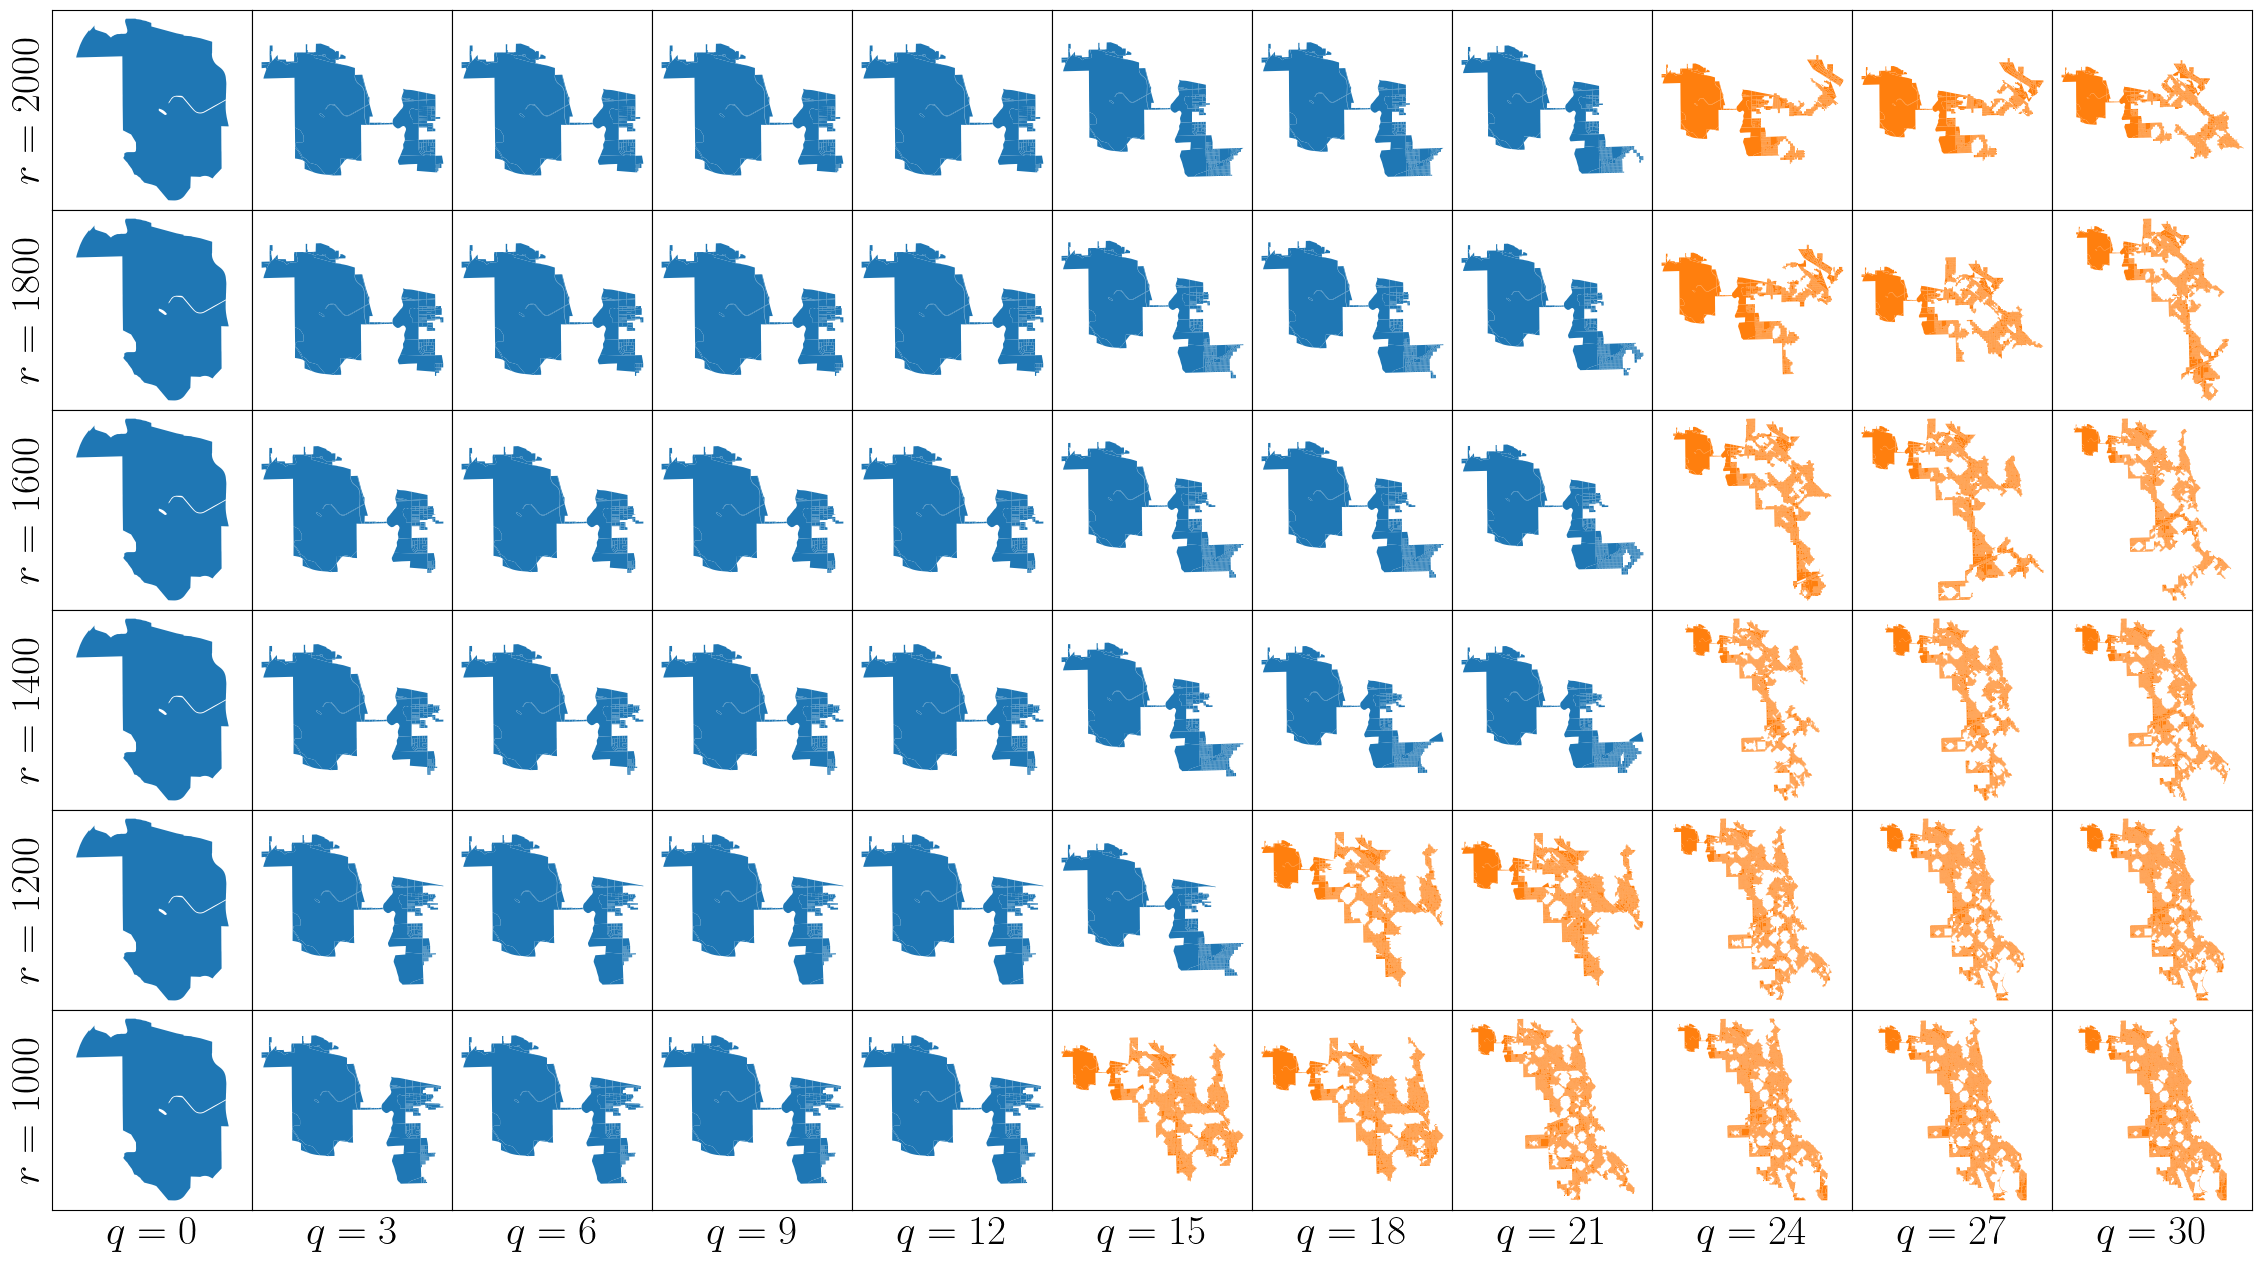

In [31]:
fig, axs = plt.subplots(len(newrs), len(newqs), figsize=(2*len(newqs),2*len(newrs)), gridspec_kw={'wspace': 0, 'hspace': 0})


for i,r in enumerate(newrs):
    for j,q in enumerate(newqs):
        G_filtered = filter_graph(G, r, q)

        comp = get_subgraph_containing_node(G_filtered, airport) 

        if len(comp)>1000:
            color='C1'
        else:
            color='C0'

        blocks[blocks.index.isin(comp)].plot(ax = axs[i, j], color=color)

        if j == 0:
            axs[i,j].set_ylabel(f'$r={r}$', fontsize=30)

        if i == len(newrs)-1:
            axs[i,j].set_xlabel(f'$q={q}$', fontsize=30)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].tick_params(left=False, bottom=False) 

        axs[i,j].set_box_aspect(1)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig('Results_Parks_Resource/PH_class.png', dpi=400, bbox_inches='tight', transparent=True)

In [32]:
G_filtered = filter_graph(G, newrs[0], newqs[0])
comp_step1 = get_subgraph_containing_node(G_filtered, airport) 

G_filtered = filter_graph(G, newrs[0], newqs[1])
comp_step2 = get_subgraph_containing_node(G_filtered, airport) 


Find component that is separate at $(r,q)=(0,0)$ but merges with airport component at $(r,q)=(0,3)$. Look at blocks that are in the component at $(0,3)$ but not in $(0,0)$ and pick one as the representative. 

In [33]:
G_filtered = filter_graph(G, newrs[0], newqs[0])
for i in list(comp_step2 - comp_step1):
    comp = get_subgraph_containing_node(G_filtered, i)
    if len(comp)>1:
        break

merge_with = list(comp)[0]

In [34]:
termcoords = [ (2000,21), (1800,21), (1600, 21), (1400, 21), (1200, 15), (1000, 12)]
termcoords_dict = {r: q for (r,q) in termcoords}
airportchunk= []
for tr, tq in termcoords:
    G_filtered = filter_graph(G, tr, tq)

    airportchunk = airportchunk + list(get_subgraph_containing_node(G_filtered, airport))

print(airportchunk)

[4105, 4121, np.int64(12315), 10274, 12323, 10278, 4143, 4144, 4145, 4146, 4147, 34879, np.int64(34880), np.int64(34889), np.int64(18507), np.int64(18508), np.int64(18511), 18513, 2142, np.int64(26730), 26731, np.int64(26732), np.int64(26733), 26734, 26735, np.int64(26736), np.int64(26737), np.int64(26738), np.int64(26740), 8324, 2183, 2184, 2185, 2186, 2187, 2188, 2189, 2190, 2193, 2194, np.int64(2196), 2197, 2205, 2206, 2207, 2208, 2209, 2210, 2211, np.int64(22730), np.int64(22739), np.int64(20708), 14565, np.int64(6373), 6372, 6375, 6376, np.int64(6377), np.int64(6381), 14576, np.int64(30971), 6449, np.int64(26948), 6505, np.int64(26989), 26991, 26992, 6519, np.int64(35214), np.int64(35217), 4525, 25023, 8644, 27079, np.int64(27080), np.int64(33247), np.int64(33249), np.int64(33250), np.int64(33251), 33252, np.int64(33253), 33254, np.int64(33255), np.int64(33256), np.int64(33257), np.int64(33258), np.int64(33259), np.int64(33260), 6630, 27118, np.int64(27110), np.int64(27127), np.in

In [35]:
merge_with

np.int64(14847)

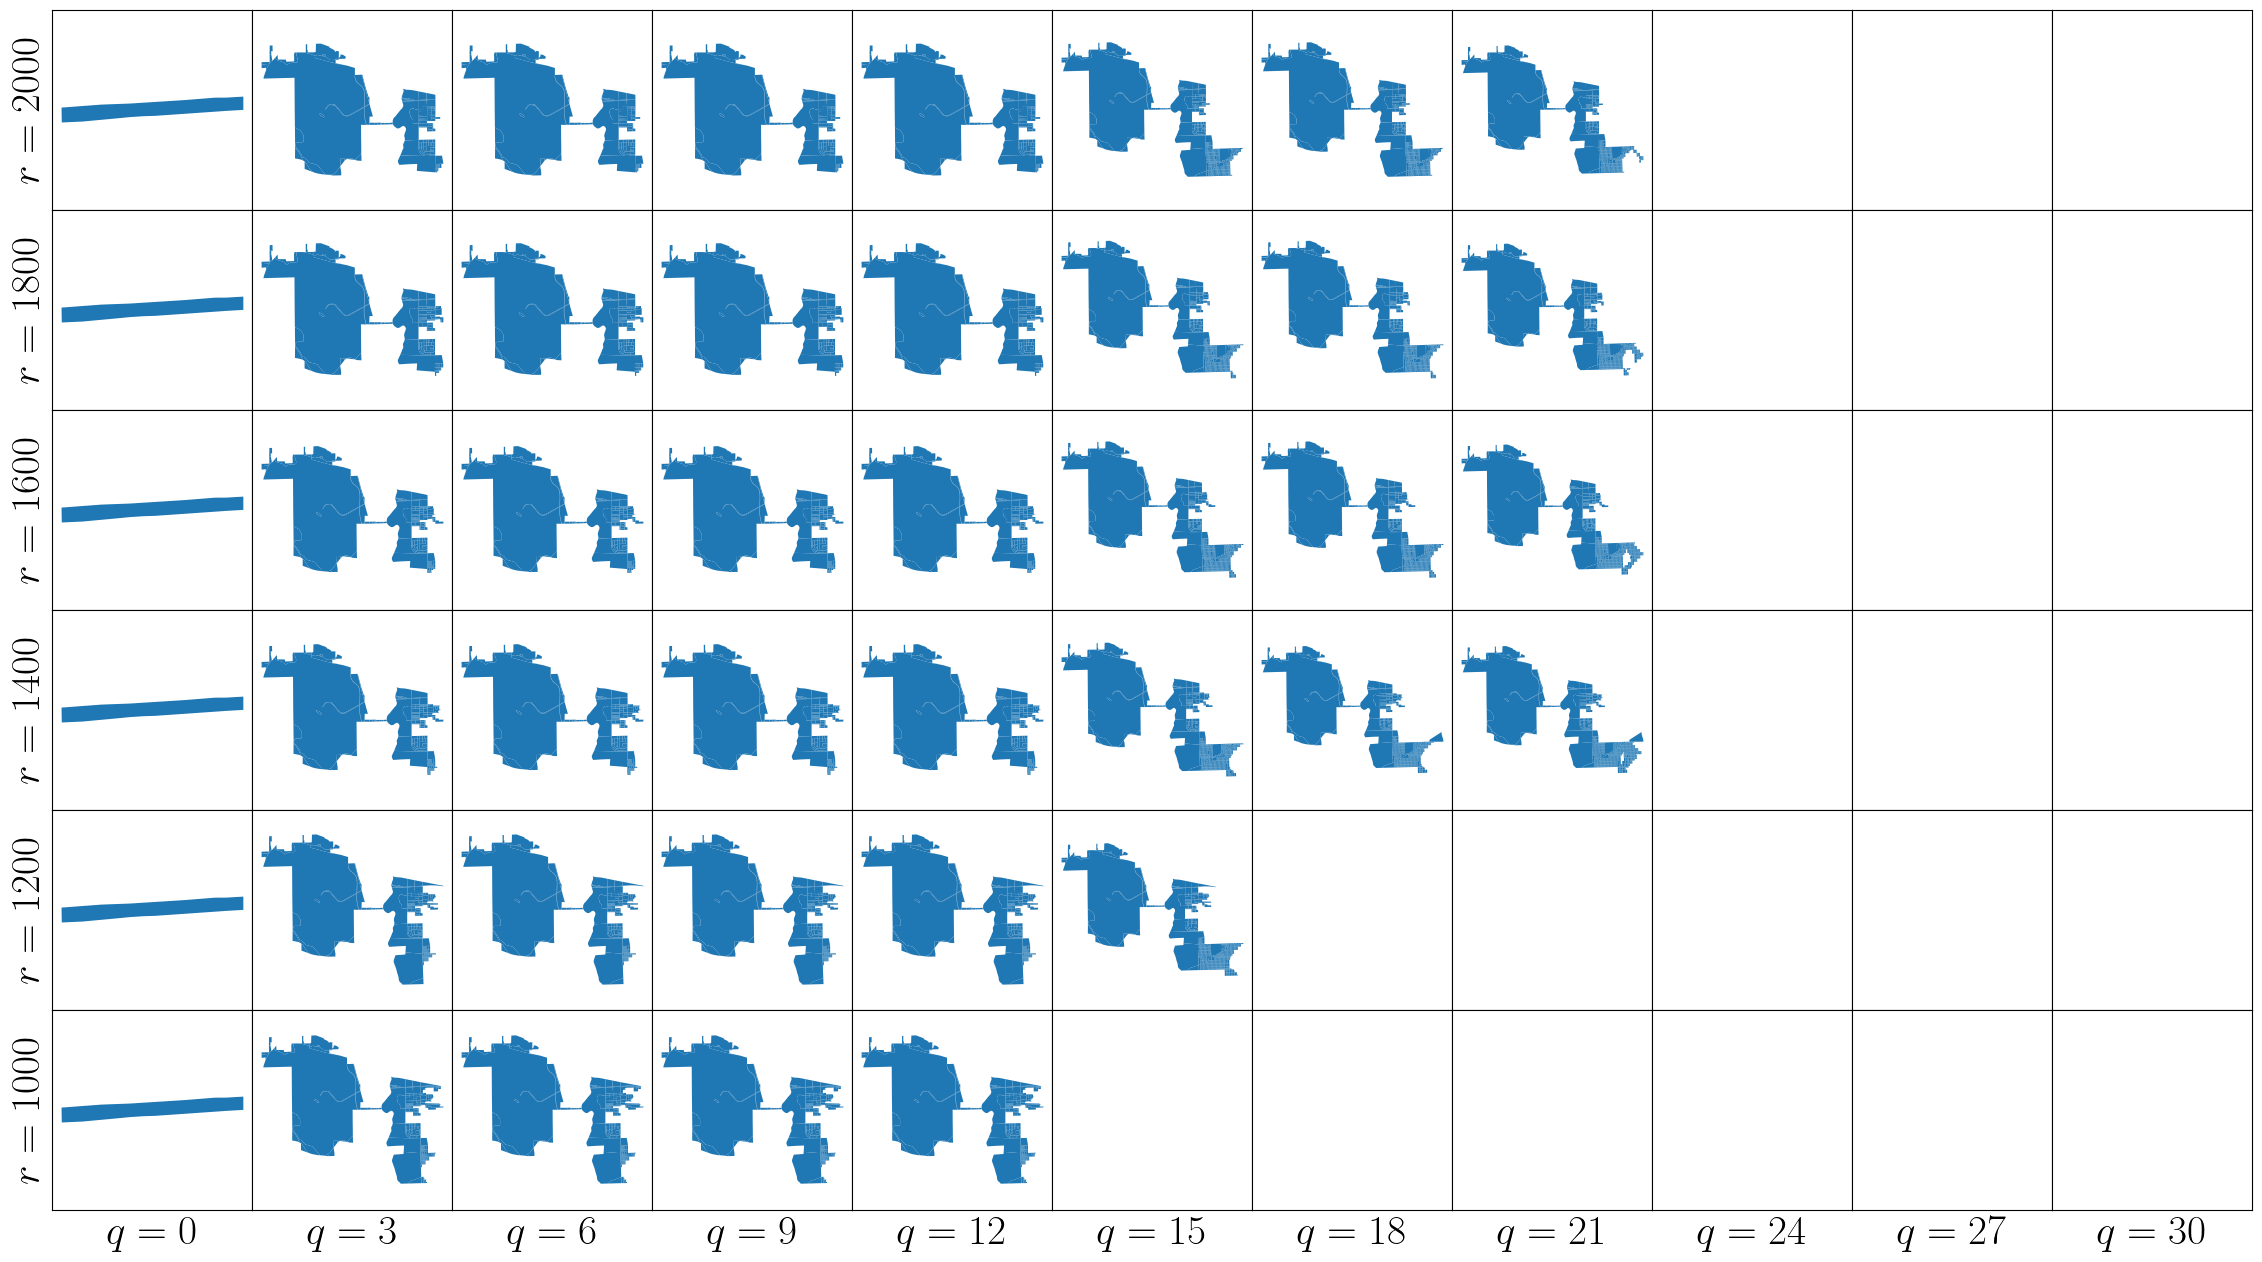

In [36]:
fig, axs = plt.subplots(len(newrs), len(newqs), figsize=(2*len(newqs),2*len(newrs)), gridspec_kw={'wspace': 0, 'hspace': 0})


airport_chunk = []
for i,r in enumerate(newrs):
    for j,q in enumerate(newqs):
        G_filtered = filter_graph(G, r, q)

        comp = get_subgraph_containing_node(G_filtered, merge_with) 

        if len(comp)<=1000:
            blocks[blocks.index.isin(comp)].plot(ax = axs[i, j], color='C0')

        if j == 0:
            axs[i,j].set_ylabel(f'$r={r}$', fontsize=30)

        if i == len(newrs)-1:
            axs[i,j].set_xlabel(f'$q={q}$', fontsize=30)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].tick_params(left=False, bottom=False) 

        axs[i,j].set_box_aspect(1)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig('Results_Parks_Resource/PH_class_truncated.png', dpi=400, bbox_inches='tight', transparent=True)

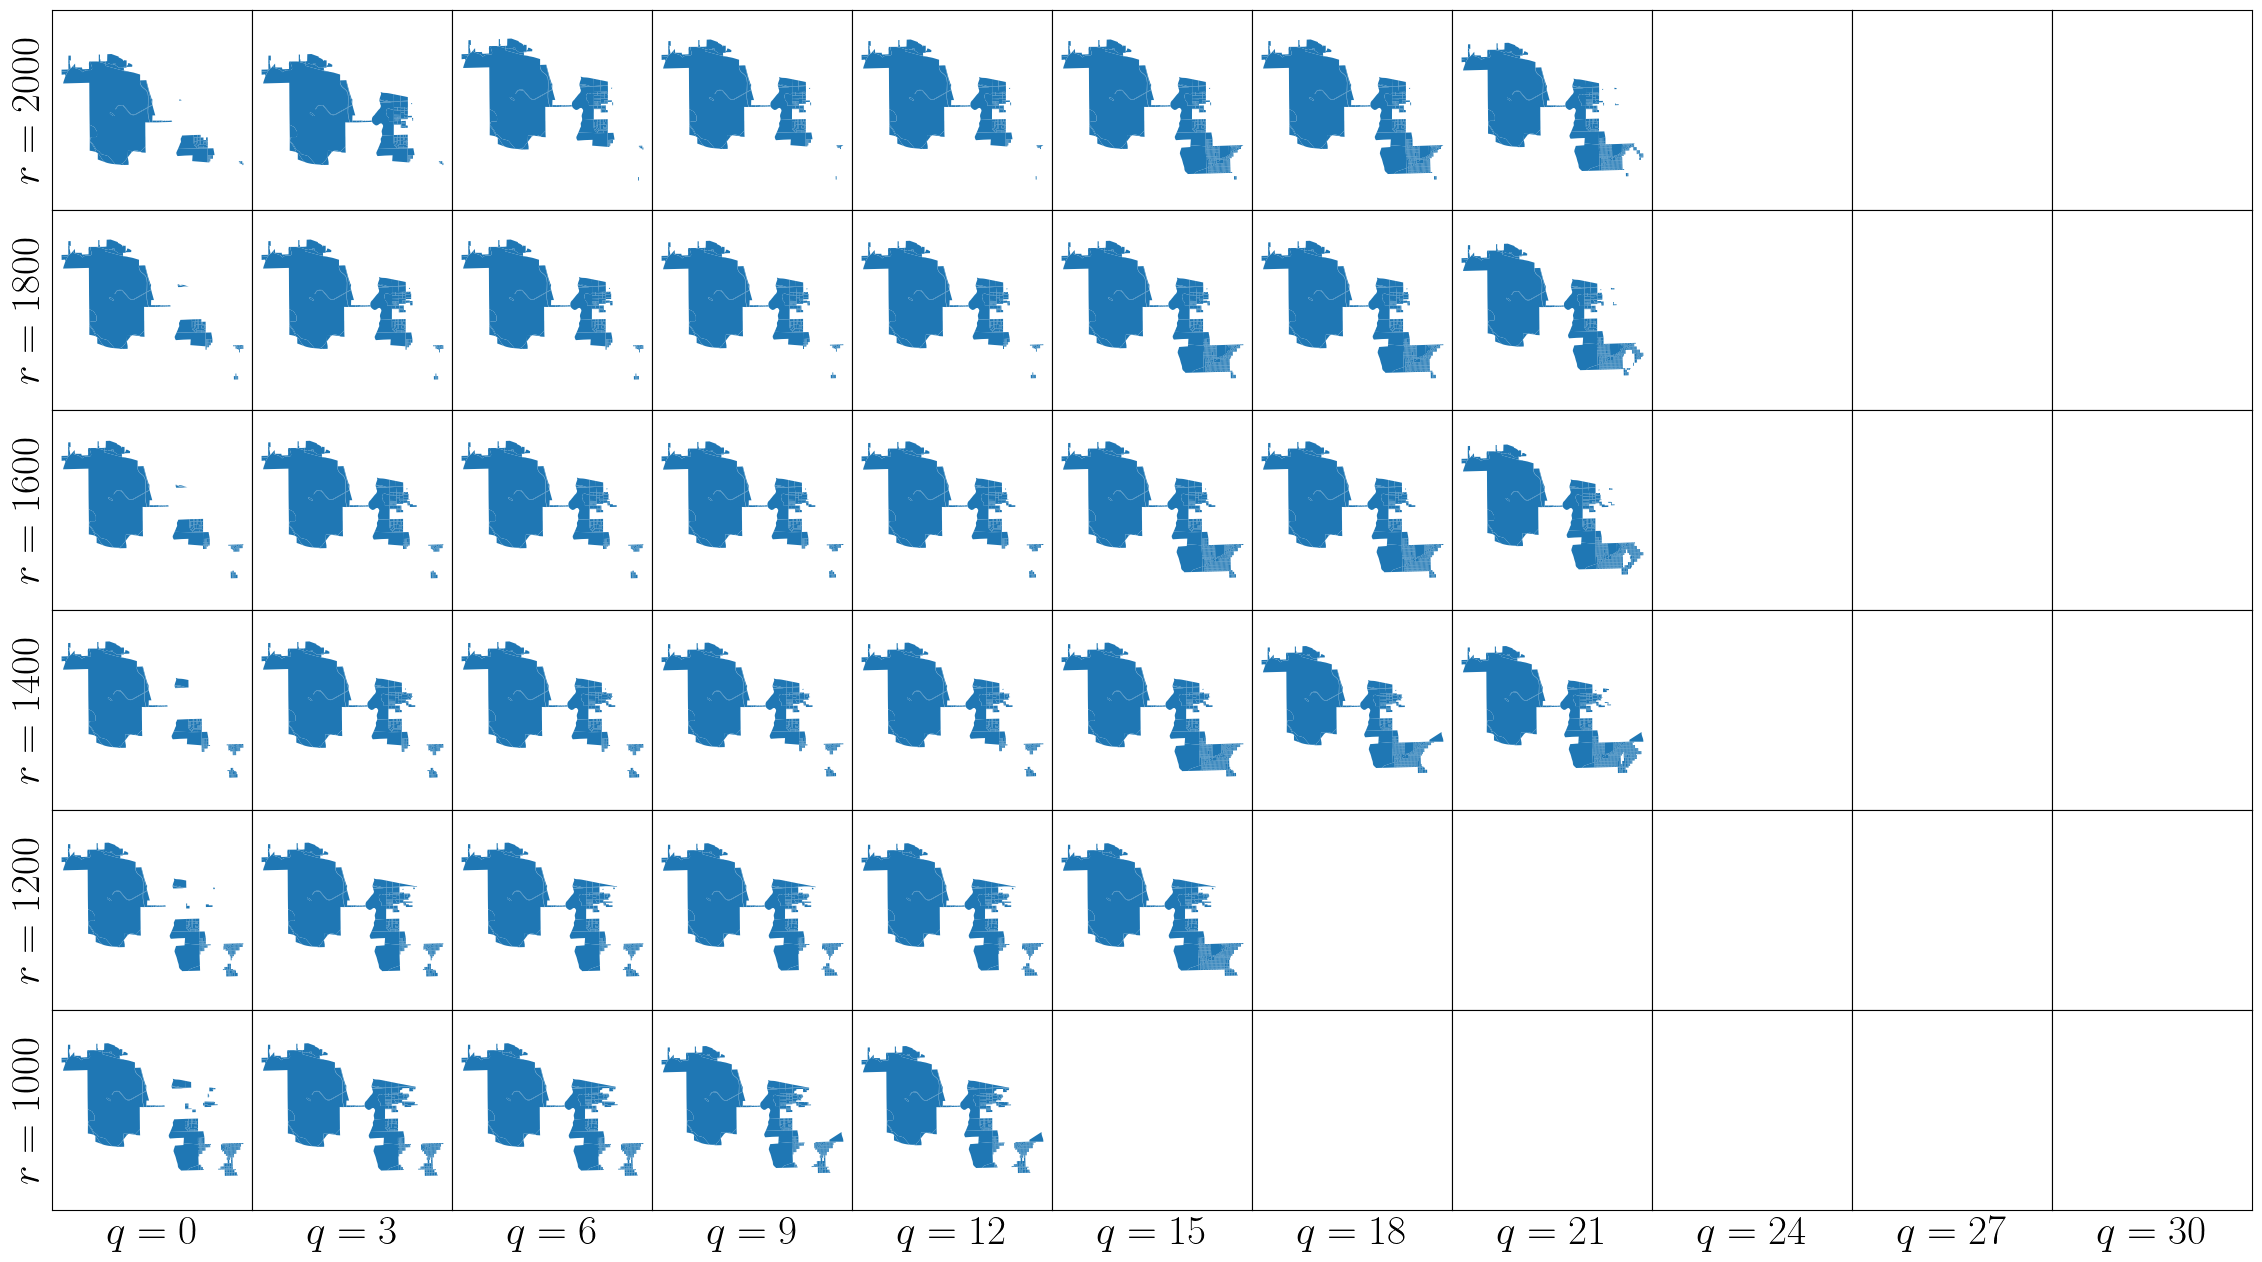

In [37]:
fig, axs = plt.subplots(len(newrs), len(newqs), figsize=(2*len(newqs),2*len(newrs)), gridspec_kw={'wspace': 0, 'hspace': 0})

compdone = []
comp = []
for i,r in enumerate(newrs):
    for j,q in enumerate(newqs):

        yesplot = []
        for k in airportchunk:
            if G.nodes[k][r] <= q:
                yesplot.append(k)
        
        if any(r == r1 and q<= q1 for (r1,q1) in termcoords):
            blocks[blocks.index.isin(yesplot)].plot(ax = axs[i, j], color='C0')

        if j == 0:
            axs[i,j].set_ylabel(f'$r={r}$', fontsize=30)

        if i == len(newrs)-1:
            axs[i,j].set_xlabel(f'$q={q}$', fontsize=30)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].tick_params(left=False, bottom=False) 

        axs[i,j].set_box_aspect(1)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig('Results_Parks_Resource/PH_class_truncated_ex3.png', dpi=400, bbox_inches='tight', transparent=True)

In [ ]:
TCC3_maxrep = np.loadtxt("TCC_3_maxrep.csv", delimiter=',')

In [ ]:
len(TCC3_maxrep)

801

<Axes: >

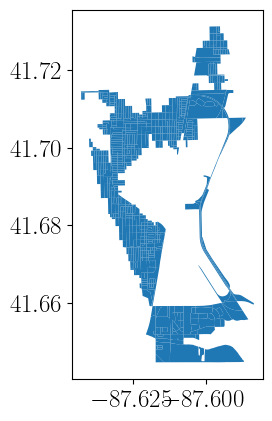

In [ ]:
blocks[blocks.index.isin(TCC3_maxrep)].plot()

 
801


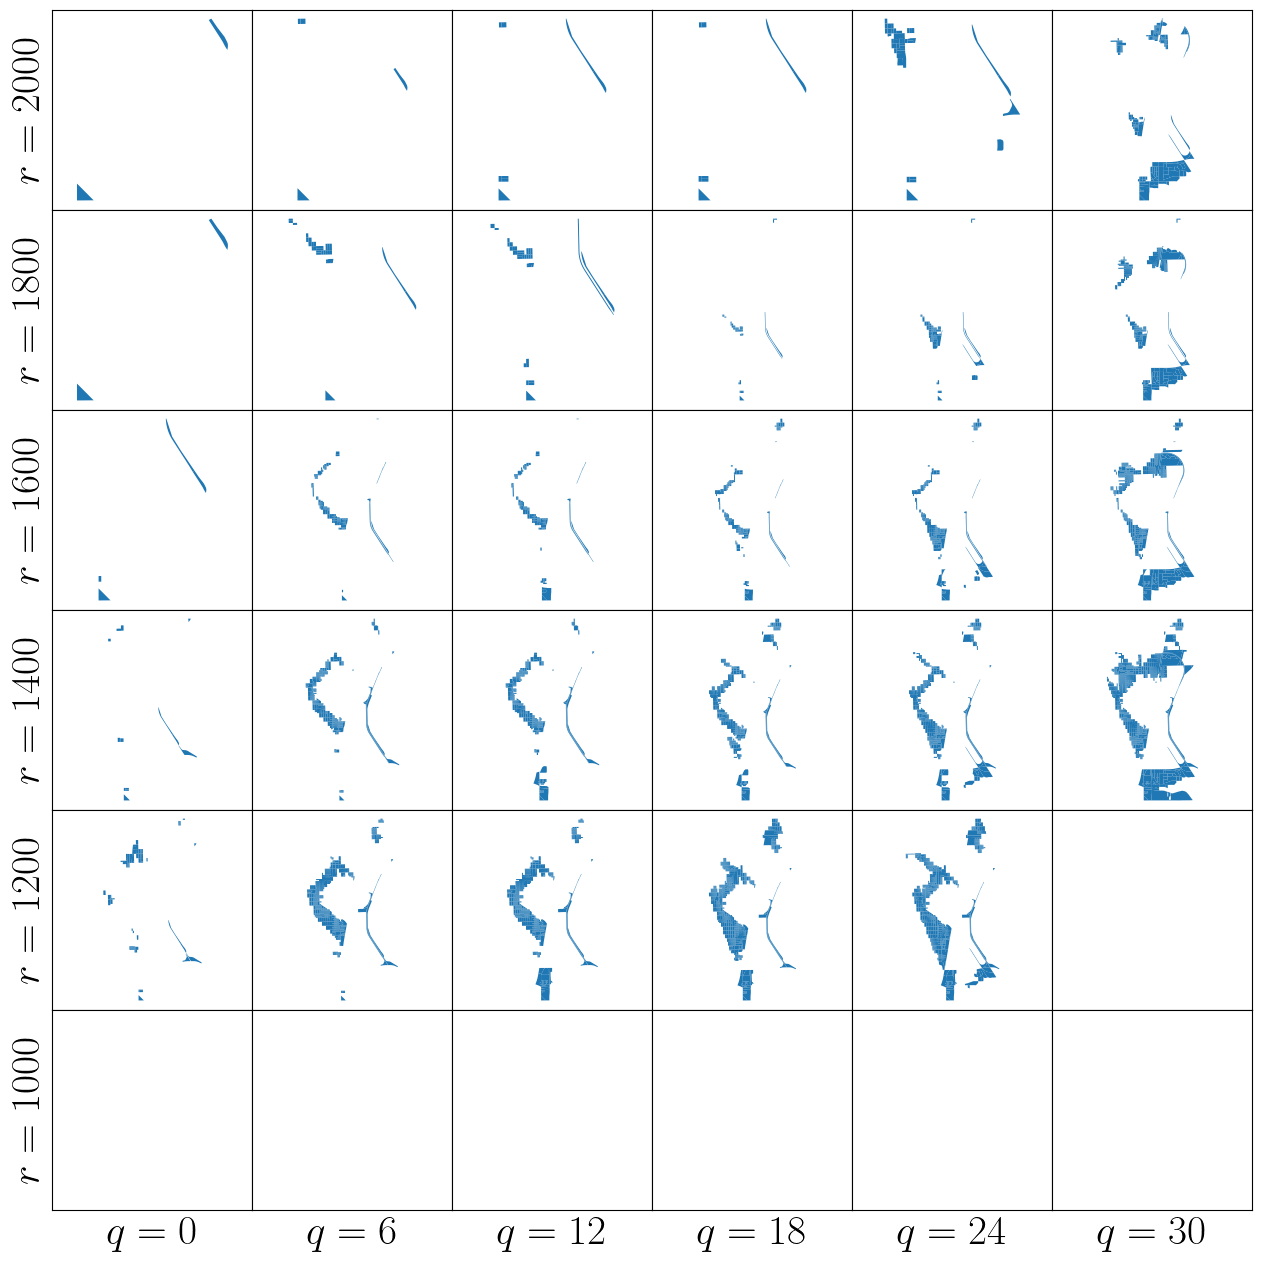

In [ ]:
newqs = np.arange(0, 31, 6)

newrs = np.arange(2000, 999, -200)

fig, axs = plt.subplots(len(newrs), len(newqs), figsize=(2*len(newqs),2*len(newrs)), gridspec_kw={'wspace': 0, 'hspace': 0})

compdone = []
comp = []
for i,r in enumerate(newrs):
    for j,q in enumerate(newqs):

        yesplot = []
        for k in TCC3_maxrep:

            if G.nodes[k][r] <= q:
                yesplot.append(k)
        
        if r == 1000 and q == 30:
            print(len(yesplot))
        
        if r>1000:
            if r == 1200 and q==30:
                print(' ')
            else:
                blocks[blocks.index.isin(yesplot)].plot(ax = axs[i, j], color='C0')

        if j == 0:
            axs[i,j].set_ylabel(f'$r={r}$', fontsize=30)

        if i == len(newrs)-1:
            axs[i,j].set_xlabel(f'$q={q}$', fontsize=30)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].tick_params(left=False, bottom=False) 

        axs[i,j].set_box_aspect(1)

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig('Results_Parks_Resource/PH_class_truncated_ex2.png', dpi=400, bbox_inches='tight', transparent=True)

<Axes: >

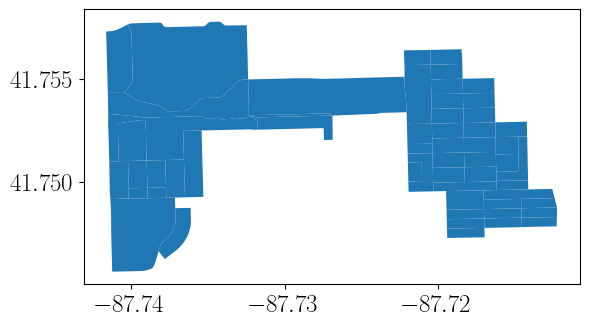

In [ ]:
TCC3_maxrep = np.loadtxt("TCC_14_maxrep.csv", delimiter=',')

blocks[blocks.index.isin(TCC3_maxrep)].plot()

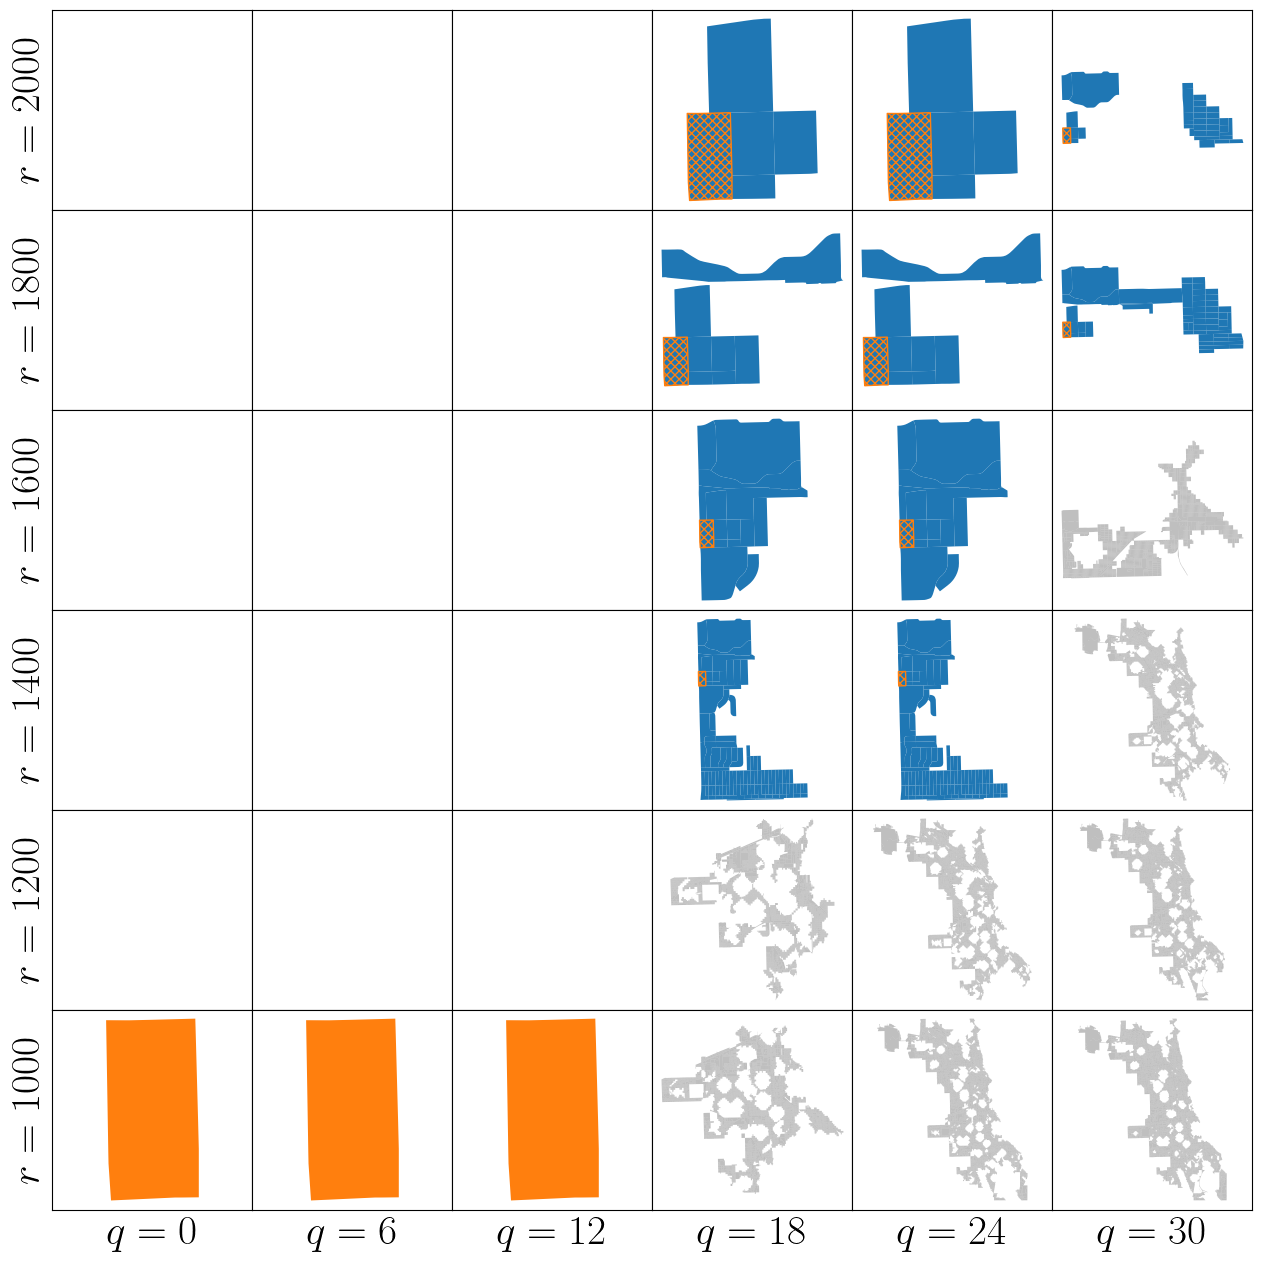

In [ ]:
newqs = np.arange(0, 31, 6)

newrs = np.arange(2000, 999, -200)

fig, axs = plt.subplots(len(newrs), len(newqs), figsize=(2*len(newqs),2*len(newrs)), gridspec_kw={'wspace': 0, 'hspace': 0})

compdone = {}
comp = []
for i,r in enumerate(newrs):
    for j,q in enumerate(newqs):

        if r>=1600 and q>=18:
            if r==1600 and q == 30:
                print(' ')
            else:
                yesplot = []
                for k in TCC3_maxrep:

                    if G.nodes[k][r] <= q:
                        yesplot.append(k)
                
                # if 18155 in yesplot:
                #     blocks[blocks.index.isin([18155])].plot(ax = axs[i, j], color='C1')
                #     yesplot.remove(18155)
                    
                if len(yesplot)>0:
                    blocks[blocks.index.isin(yesplot)].plot(ax = axs[i, j], color='C0')

                G_filtered = filter_graph(G, r, q)

                blocks[blocks.index.isin([18155])].plot(ax = axs[i, j], color=None, hatch='xxxx', edgecolor='C1')

                compdone[(r,q)] = yesplot

        elif r==1000 and q<=12:
            blocks[blocks.index.isin([18155])].plot(ax = axs[i, j], color='C1')

        if (r,q) in [(1000,18), (1000,24), (1000,30), (1200,18), (1200,24), (1200,30), (1400,18), (1400,24), (1400,30), (1600,30)]:
            G_filtered = filter_graph(G, r, q)

            comp = get_subgraph_containing_node(G_filtered, 18155) 
            if len(comp) > 1000:
                blocks[blocks.index.isin(comp)].plot(ax = axs[i, j], color='grey', alpha=0.5, zorder=-100)
                # 
            else:
                blocks[blocks.index.isin(comp)].plot(ax = axs[i, j], color='C0', zorder=0)
                blocks[blocks.index.isin([18155])].plot(ax = axs[i, j], color=None, hatch='xxxx', edgecolor='C1')
                compdone[(r,q)] = comp
            
            

            # if q == 18 or q == 24:
            #     blocks[blocks.index.isin(compdone[(1400,q)])].plot(ax = axs[i, j], color='C0', zorder=0)
            # elif q == 30:
            #     blocks[blocks.index.isin(compdone[(1800,q)])].plot(ax = axs[i, j], color='C0', zorder=0)
            #     if r == 1600 or r == 1400:
            #         blocks[blocks.index.isin(compdone[(r,24)])].plot(ax = axs[i, j], color='C0', zorder=0)
            #     elif r == 1200 or r == 1000:
            #         blocks[blocks.index.isin(compdone[(1400,24)])].plot(ax = axs[i, j], color='C0', zorder=0)

        if j == 0:
            axs[i,j].set_ylabel(f'$r={r}$', fontsize=30)

        if i == len(newrs)-1:
            axs[i,j].set_xlabel(f'$q={q}$', fontsize=30)

        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].tick_params(left=False, bottom=False) 
        axs[i,j].set_box_aspect(1)
        

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig('Results_Parks_Resource/PH_class_weird_merge.png', dpi=400, bbox_inches='tight', transparent=True)